# ISNet Training Experiment

## Objective

The objective of this notebook is to understand the workflow of training a segmentation model using an open dataset, experiment tracking with Weights & Biases (wandb), and performing inference on unseen images.

In [3]:
!git clone https://github.com/xuebinqin/DIS.git

Cloning into 'DIS'...
remote: Enumerating objects: 361, done.
remote: Counting objects: 100% (181/181), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 361 (delta 157), reused 130 (delta 130), pack-reused 180 (from 1)
Receiving objects: 100% (361/361), 49.63 MiB | 36.56 MiB/s, done.
Resolving deltas: 100% (176/176), done.


## Environment Setup

The required dependencies are installed and the Weights & Biases (wandb) environment is configured for experiment tracking.

In [7]:
!pip install wandb

In [8]:
%%writefile /content/DIS/requirements.txt
torch
torchvision
numpy
pillow
matplotlib
wandb
opencv-python

Overwriting /content/DIS/requirements.txt


In [9]:
!pip install -r /content/DIS/requirements.txt

In [10]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 1


wandb: You chose 'Create a W&B account'
wandb: Create an account here: https://wandb.ai/authorize?signup=true&ref=models
wandb: After creating your account, create a new API key and store it securely.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: abiramesh2023 (abiramesh2023-kgisl-institute-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Dataset Preparation

The Oxford-IIIT Pet dataset is used for this experiment. The dataset contains images and corresponding segmentation masks that can be used for foreground-background segmentation tasks.

In [13]:
from torchvision.datasets import OxfordIIITPet

dataset = OxfordIIITPet(
    root="data",
    download=True,
    target_types="segmentation"
)

print("Dataset Size:", len(dataset))

100%|██████████| 792M/792M [00:27<00:00, 28.5MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 13.8MB/s]


Dataset Size: 3680


## Dataset Visualization

A sample image and its corresponding segmentation mask are displayed to verify that the dataset has been loaded correctly.

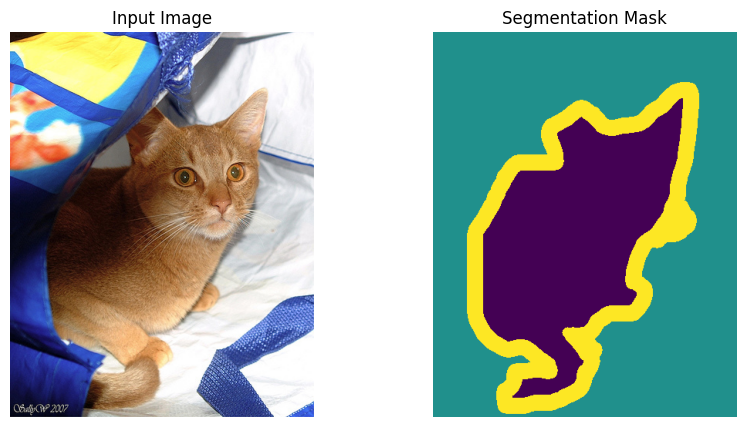

In [14]:
import matplotlib.pyplot as plt

image, mask = dataset[0]

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask)
plt.title("Segmentation Mask")
plt.axis("off")

plt.show()

In [15]:
!mkdir -p isnet_project
%cd isnet_project

/content/isnet_project


In [16]:
%%writefile dataset.py

from torchvision.datasets import OxfordIIITPet

def get_dataset():
    dataset = OxfordIIITPet(
        root="data",
        download=True,
        target_types="segmentation"
    )
    return dataset

Writing dataset.py


In [17]:
import wandb

run = wandb.init(
    project="isnet-training",
    name="dataset-test"
)

wandb.log({"dataset_size": len(dataset)})

run.finish()

dataset_size,▁
dataset_size,3680


## Model Architecture

A lightweight segmentation model is implemented to understand the training workflow. The model consists of an encoder for feature extraction and a decoder for mask prediction.

In [18]:
%%writefile model.py

import torch
import torch.nn as nn

class SimpleSegModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(16, 1, 2, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

Writing model.py


In [19]:
from model import SimpleSegModel
import torch

model = SimpleSegModel()

dummy = torch.randn(1,3,256,256)

output = model(dummy)

print(output.shape)

torch.Size([1, 1, 256, 256])


## Model Training

The model is trained using Binary Cross Entropy (BCE) loss and the Adam optimizer. Weights & Biases (wandb) is used to track training metrics.

In [20]:
%%writefile train.py

import wandb

wandb.init(
    project="isnet-training",
    name="training-run"
)

print("Training pipeline initialized")

wandb.finish()

Writing train.py


In [21]:
!python train.py

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: abiramesh2023 (abiramesh2023-kgisl-institute-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: ⢿ setting up run 1d3wxvkk (0.0s)
wandb: ⣻ setting up run 1d3wxvkk (0.0s)
wandb: ⣽ setting up run 1d3wxvkk (0.0s)
wandb: Tracking run with wandb version 0.27.1
wandb: Run data is saved locally in /content/isnet_project/wandb/run-20260610_083807-1d3wxvkk
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run training-run
wandb: ⭐️ View project at https://wandb.ai/abiramesh2023-kgisl-institute-of-technology/isnet-training
wandb: 🚀 View run at https://wandb.ai/abiramesh2023-kgisl-institute-of-technology/isnet-training/runs/1d3wxvkk
Training pipeline initialized
wandb: ⢿ updating run metadata (0.7s)
wandb: ⢿ uploading console lines 0-0 (0.0s)
wandb: ⣻ updating run met

In [24]:
%%writefile dataset.py

from torchvision.datasets import OxfordIIITPet
from torchvision import transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

def get_dataloader(batch_size=4):

    dataset = OxfordIIITPet(
        root="data",
        download=True,
        target_types="segmentation",
        transform=transform
    )

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True
    )

Overwriting dataset.py


In [26]:
!cat dataset.py


from torchvision.datasets import OxfordIIITPet
from torchvision import transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

def get_dataloader(batch_size=4):

    dataset = OxfordIIITPet(
        root="data",
        download=True,
        target_types="segmentation",
        transform=transform
    )

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True
    )


In [28]:
%%writefile dataset.py

from torchvision.datasets import OxfordIIITPet
from torchvision import transforms
from torch.utils.data import DataLoader

image_transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

mask_transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

def get_dataloader(batch_size=4):

    dataset = OxfordIIITPet(
        root="data",
        download=True,
        target_types="segmentation",
        transform=image_transform,
        target_transform=mask_transform
    )

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True
    )

Overwriting dataset.py


In [29]:
import importlib
import dataset

importlib.reload(dataset)

from dataset import get_dataloader

In [30]:
loader = get_dataloader()

images, masks = next(iter(loader))

print("Images Shape:", images.shape)
print("Masks Shape:", masks.shape)

Images Shape: torch.Size([4, 3, 256, 256])
Masks Shape: torch.Size([4, 1, 256, 256])


In [31]:
%%writefile train.py

import torch
import torch.nn as nn
import torch.optim as optim
import wandb

from dataset import get_dataloader
from model import SimpleSegModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

wandb.init(
    project="isnet-training",
    name="isnet-segmentation-run"
)

loader = get_dataloader(batch_size=4)

model = SimpleSegModel().to(device)

criterion = nn.BCELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 2

for epoch in range(epochs):

    running_loss = 0

    for images, masks in loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, masks)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader)

    print(
        f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}"
    )

    wandb.log({
        "epoch": epoch + 1,
        "loss": avg_loss
    })

torch.save(
    model.state_dict(),
    "isnet_model.pth"
)

print("Model Saved")

wandb.finish()

Overwriting train.py


In [32]:
!python train.py

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: abiramesh2023 (abiramesh2023-kgisl-institute-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: ⢿ setting up run m1mqetst (0.0s)
wandb: ⣻ setting up run m1mqetst (0.0s)
wandb: ⣽ setting up run m1mqetst (0.0s)
wandb: Tracking run with wandb version 0.27.1
wandb: Run data is saved locally in /content/isnet_project/wandb/run-20260610_084553-m1mqetst
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run isnet-segmentation-run
wandb: ⭐️ View project at https://wandb.ai/abiramesh2023-kgisl-institute-of-technology/isnet-training
wandb: 🚀 View run at https://wandb.ai/abiramesh2023-kgisl-institute-of-technology/isnet-training/runs/m1mqetst
Epoch 1/2 | Loss: 0.0577
Epoch 2/2 | Loss: 0.0424
Model Saved
wandb: ⢿ updating run metadata (0.0s)
wandb: ⣻ updating run metad

## Inference

The trained model is loaded and used to generate segmentation masks for unseen images.

In [46]:
%%writefile inference.py

import torch
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

from model import SimpleSegModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleSegModel().to(device)

model.load_state_dict(
    torch.load("isnet_model.pth", map_location=device)
)

model.eval()

transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

image = Image.open("test.jpg").convert("RGB")

input_tensor = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(input_tensor)

mask = output.squeeze().cpu().numpy()

plt.imshow(mask, cmap="gray")
plt.title("Predicted Segmentation Mask")
plt.axis("off")

plt.savefig("prediction.png")
print("Prediction saved as prediction.png")

plt.show()

Overwriting inference.py


In [47]:
!python inference.py

Prediction saved as prediction.png
Figure(640x480)


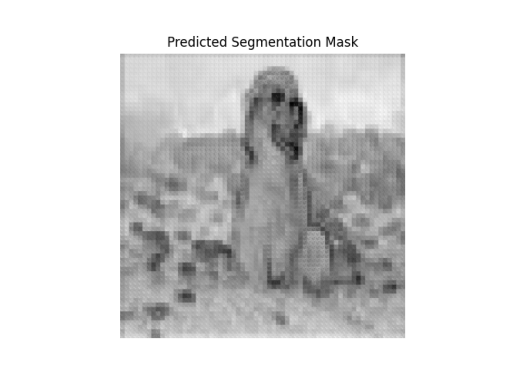

In [49]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("prediction.png")

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

## Observations

- The training loss decreased from 0.0577 to 0.0424.
- wandb successfully tracked the training metrics.
- The model generated segmentation masks for new images.
- The experiment demonstrated the complete workflow of dataset preparation, training, model saving, and inference.